# NRLMSIS 2.1 — Demo Notebook

This notebook demonstrates the Python translation of the **NRLMSIS 2.1** empirical atmospheric model.
The model computes temperature and number densities of 10 atmospheric species from the surface to ~2000 km.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nrlmsis import NRLMSIS21

model = NRLMSIS21()
print('Model loaded.')

Model loaded.


## 1. Single-point calculation

Compute temperature and densities at a specific location, time, and solar conditions.

In [2]:
# Geomagnetic activity index array (7 elements)
ap = np.array([7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0])

result = model.calc(
    day=172,        # day of year (summer solstice)
    utsec=43200.0,  # 12:00 UT in seconds
    z=300.0,        # altitude (km)
    lat=45.0,       # geodetic latitude (degrees N)
    lon=-75.0,      # geodetic longitude (degrees E)
    sfluxavg=150.0, # 81-day average F10.7 (solar flux units)
    sflux=150.0,    # daily F10.7 for previous day
    ap=ap,
)

print(f'Temperature at 300 km:  {result.temperature:.1f} K')
print(f'Exospheric temperature: {result.exospheric_temperature:.1f} K')
print()

species = ['mass density', 'N2', 'O2', 'O', 'He', 'H', 'Ar', 'N', 'Anom-O', 'NO']
units   = ['kg/m\u00b3'] + ['m\u207b\u00b3'] * 9
for name, unit, val in zip(species, units, result.densities):
    print(f'  {name:<14} {val:12.4e}  {unit}')

Temperature at 300 km:  1098.2 K
Exospheric temperature: 1130.0 K

  mass density     1.5728e-11  kg/m³
  N2               1.2981e+14  m⁻³
  O2               5.1934e+12  m⁻³
  O                3.4887e+14  m⁻³
  He               1.5359e+12  m⁻³
  H                6.8663e+10  m⁻³
  Ar               6.1264e+10  m⁻³
  N                5.6043e+12  m⁻³
  Anom-O           5.1460e+07  m⁻³
  NO               1.2735e+11  m⁻³


## 2. Altitude profile

Sweep altitude from 0 to 500 km and plot temperature and major species densities.

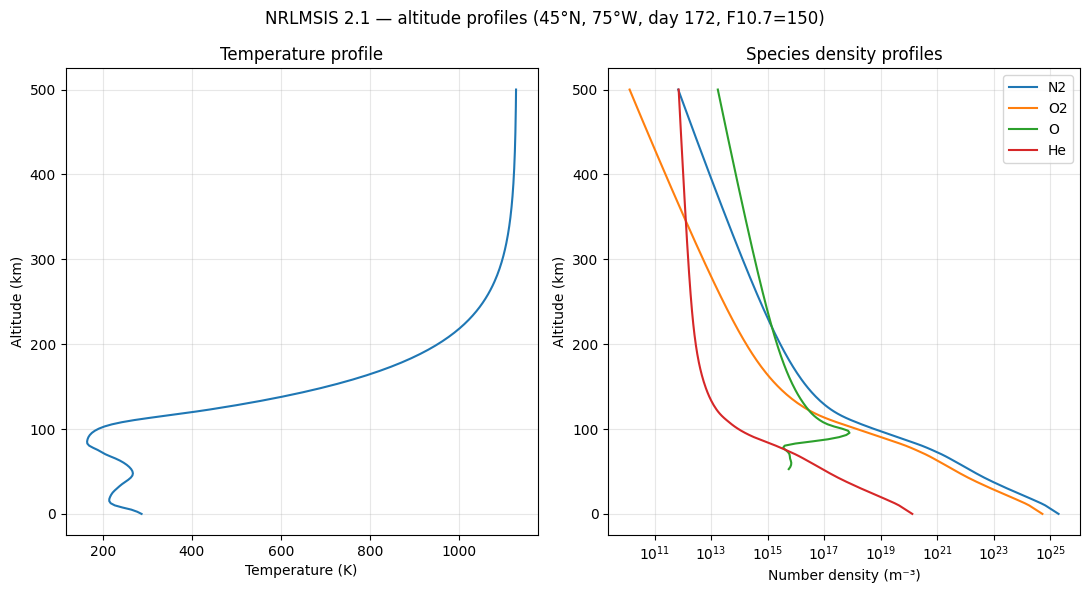

In [3]:
altitudes = np.linspace(0, 500, 200)  # km

temps  = []
dn_N2  = []
dn_O2  = []
dn_O   = []
dn_He  = []

for z in altitudes:
    r = model.calc(172, 43200.0, z, 45.0, -75.0, 150.0, 150.0, ap)
    temps.append(r.temperature)
    dn_N2.append(r.densities[1])
    dn_O2.append(r.densities[2])
    dn_O.append(r.densities[3])
    dn_He.append(r.densities[4])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6))

ax1.plot(temps, altitudes)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Altitude (km)')
ax1.set_title('Temperature profile')
ax1.grid(True, alpha=0.3)

for label, dn in [('N2', dn_N2), ('O2', dn_O2), ('O', dn_O), ('He', dn_He)]:
    # mask missing values
    vals = np.array(dn)
    mask = vals > 1e-30
    ax2.semilogx(np.where(mask, vals, np.nan), altitudes, label=label)
ax2.set_xlabel('Number density (m\u207b\u00b3)')
ax2.set_ylabel('Altitude (km)')
ax2.set_title('Species density profiles')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('NRLMSIS 2.1 — altitude profiles (45°N, 75°W, day 172, F10.7=150)')
plt.tight_layout()
plt.show()

## 3. Latitude variation

Fix altitude at 300 km and scan latitude from -90° to +90°.

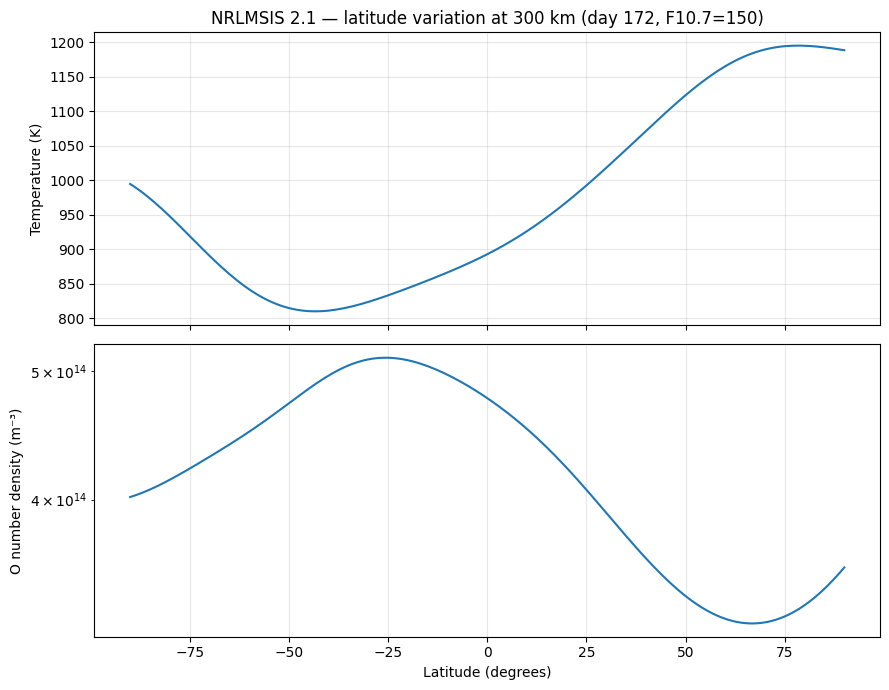

In [4]:
lats = np.linspace(-90, 90, 181)

lat_temps = []
lat_O     = []

for lat in lats:
    r = model.calc(172, 43200.0, 300.0, lat, -75.0, 150.0, 150.0, ap)
    lat_temps.append(r.temperature)
    lat_O.append(r.densities[3])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(lats, lat_temps)
ax1.set_ylabel('Temperature (K)')
ax1.set_title('NRLMSIS 2.1 — latitude variation at 300 km (day 172, F10.7=150)')
ax1.grid(True, alpha=0.3)

ax2.semilogy(lats, np.array(lat_O).clip(1))
ax2.set_xlabel('Latitude (degrees)')
ax2.set_ylabel('O number density (m\u207b\u00b3)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Diurnal variation

Fix location at 45°N / 0°E and altitude 300 km; scan UT from midnight to midnight.

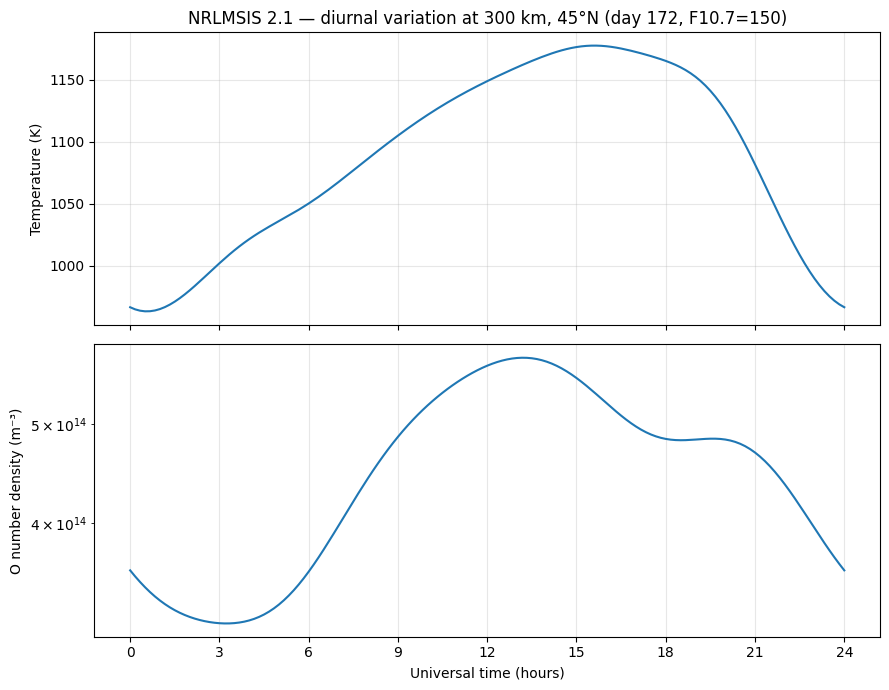

In [5]:
ut_seconds = np.linspace(0, 86400, 145)

diurnal_temps = []
diurnal_O     = []

for utsec in ut_seconds:
    r = model.calc(172, utsec, 300.0, 45.0, 0.0, 150.0, 150.0, ap)
    diurnal_temps.append(r.temperature)
    diurnal_O.append(r.densities[3])

lt_hours = ut_seconds / 3600.0  # local time = UT at 0° longitude

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(lt_hours, diurnal_temps)
ax1.set_ylabel('Temperature (K)')
ax1.set_title('NRLMSIS 2.1 — diurnal variation at 300 km, 45°N (day 172, F10.7=150)')
ax1.grid(True, alpha=0.3)

ax2.semilogy(lt_hours, np.array(diurnal_O).clip(1))
ax2.set_xlabel('Universal time (hours)')
ax2.set_ylabel('O number density (m\u207b\u00b3)')
ax2.set_xticks(range(0, 25, 3))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Legacy `gtd8d` interface

`gtd8d()` is a drop-in replacement for the original Fortran NRLMSISE-00 calling convention.
It uses CGS units and encodes year+day as an integer `YYDDD`.

In [6]:
# YYDDD: year 10 (2010), day 172
d, t = model.gtd8d(
    iyd=10172,
    sec=43200.0,
    alt=300.0,
    glat=45.0,
    glong=-75.0,
    stl=0.0,       # local solar time (ignored; computed internally)
    f107a=150.0,
    f107=150.0,
    ap=ap,
)

print('Legacy gtd8d output (CGS units):')
print(f'  Exospheric temperature: {t[0]:.1f} K')
print(f'  Temperature at alt:     {t[1]:.1f} K')
print()

legacy_species = ['He', 'O', 'N2', 'O2', 'Ar', 'rho', 'H', 'N', 'Anom-O', 'NO']
legacy_units   = ['cm\u207b\u00b3'] * 5 + ['g/cm\u00b3'] + ['cm\u207b\u00b3'] * 4
for name, unit, val in zip(legacy_species, legacy_units, d):
    print(f'  d[{legacy_species.index(name)}]  {name:<8} {float(val):12.4e}  {unit}')

# Convert O density to SI
print(f'\nO in SI units: {float(d[1]) * 1e6:.4e} m\u207b\u00b3')

Legacy gtd8d output (CGS units):
  Exospheric temperature: 1130.0 K
  Temperature at alt:     1098.2 K

  d[0]  He         1.5359e+06  cm⁻³
  d[1]  O          3.4887e+08  cm⁻³
  d[2]  N2         1.2981e+08  cm⁻³
  d[3]  O2         5.1934e+06  cm⁻³
  d[4]  Ar         6.1264e+04  cm⁻³
  d[5]  rho        1.5728e-14  g/cm³
  d[6]  H          6.8663e+04  cm⁻³
  d[7]  N          5.6043e+06  cm⁻³
  d[8]  Anom-O     5.1460e+01  cm⁻³
  d[9]  NO         1.2735e+05  cm⁻³

O in SI units: 3.4887e+14 m⁻³
